# Distance to TLS and bronchi — visualization
Visualization of the distance-to-TLS / distance-to-bronchi analysis. 

**Pinned Environment:** [`conda_envs/space2_20250604.yml`](../conda_envs/space2_20250604.yml)  

In [ ]:
from pathlib import Path
import sys
import os
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import squidpy as sq

from scipy.spatial.distance import jensenshannon
from scipy.ndimage import gaussian_filter

import pickle
import joblib

import matplotlib.colors as mcolors

import matplotlib as mpl
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['pdf.fonttype'] = 42

warnings.simplefilter(action='ignore', category=Warning)

## Local file info

In [2]:
sys.path.append(str(Path.cwd().resolve().parents[0]))

from config.paths import BASE_OUTDIR, INPUTS_DIR, FUNCTIONS_DIR

inputs_dir = INPUTS_DIR
structures_dir = os.path.join(BASE_OUTDIR, "structures")
out_dir = os.path.join(BASE_OUTDIR, "downstream_analysis")

plot_out_dir = os.path.join(out_dir, 'plots')

In [98]:
import importlib
if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.append(str(FUNCTIONS_DIR))

import plotting_utils as pu
import de_utils as du

import distance_utils
importlib.reload(distance_utils)
from distance_utils import plot_celltype_density_2d, scvelo_heatmap, distance_xy_kde


In [99]:
importlib.reload(du)
importlib.reload(distance_utils)

<module 'distance_utils' from '/home/workspace/spatial_tls_manuscript/utils/distance_utils.py'>

## Load adata
Loads the output of `02_distance_tls_bronchi.ipynb`.

In [5]:
adata = sc.read_h5ad(os.path.join(out_dir, 'adata_distance.h5ad'))

## Load palettes

In [6]:
with open(os.path.join(inputs_dir, 'palettes/20250519_celltype_palette_mapped.pkl'), 'rb') as f:
    celltype_palette_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250520_celltype_palette_coarse_mapped.pkl'), 'rb') as f:
    celltype_palette_coarse_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250520_celltype_palette_coarser_mapped.pkl'), 'rb') as f:
    celltype_palette_coarser_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250521_zone_consol_palette_mapped.pkl'), 'rb') as f:
    zone_consol_palette_mapped = pickle.load(f)

In [7]:
import matplotlib.colors as clr
import colorcet

zissou = [
    "#3A9AB2",
    "#6FB2C1",
    "#91BAB6",
    "#A5C2A3",
    "#BDC881",
    "#DCCB4E",
    "#E3B710",
    "#E79805",
    "#EC7A05",
    "#EF5703",
    "#F11B00",
]

colormap = clr.LinearSegmentedColormap.from_list("Zissou", zissou)
colormap_r = clr.LinearSegmentedColormap.from_list("Zissou", zissou[::-1])

## Spatial plots of distance

In [8]:
# Make color bars for plot
import matplotlib.cm as cm
# Define the colormap
cmap = cm.viridis  # or e.g., cm.viridis_r, cm.Reds, etc.
# cmap = colormap_r

# Create a dummy scalar mappable for the colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)

# Create a new figure and axis
fig, ax = plt.subplots(figsize=(1, 4))  # adjust size as needed

# Add the colorbar to the axis
cb = fig.colorbar(sm, cax=ax)

# Remove ticks and labels
cb.ax.set_yticks([])
cb.ax.set_yticklabels([])

# Remove outline
cb.outline.set_visible(False)

# Save the figure
fig.savefig(os.path.join(plot_out_dir, "colormap_viridis_clean.png"), dpi=300, bbox_inches='tight', transparent=True)
# fig.savefig(os.path.join(plot_out_dir, "colormap_r_redblue_clean.png"), dpi=300, bbox_inches='tight', transparent=True)
plt.close(fig)

In [ ]:
adata_d3 = adata[adata.obs['sample_label']=='HDM_day3', :]
adata_d30 = adata[adata.obs['sample_label']=='HDM_day30', :]

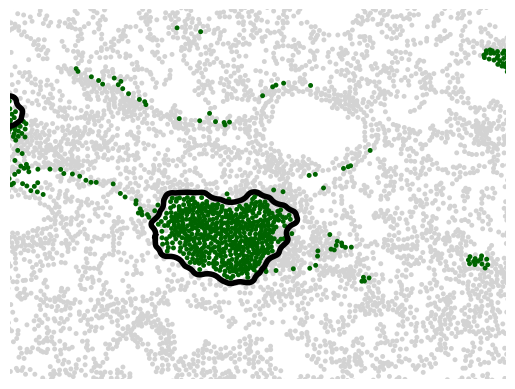

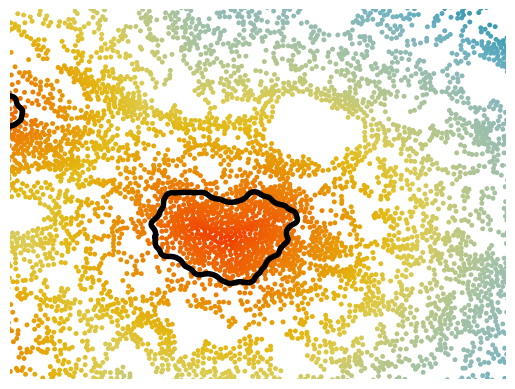

In [9]:
sample_label = 'HDM_day3'
adata_d3 = adata[adata.obs['sample_label'] == sample_label, :]
adata_plot = adata_d3.copy()
adata_plot.obs['zone_consol_temp'] = adata_plot.obs['zone_consol'].copy()
adata_plot.obs.loc[adata_plot.obs['zone_consol'] != 'TLS', 'zone_consol_temp'] = np.nan
sc.pl.embedding(adata_plot, basis='spatial', color='zone_consol_temp',
                palette = zone_consol_palette_mapped,
                frameon=False, 
                size=50, 
                title = '',
                legend_loc = 'none',
                show=False)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(structures_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=4)
   
plt.xlim([3700, 4400])
plt.ylim([4200, 4900])
plt.savefig(os.path.join(plot_out_dir, "zone_day3_tls_zoom.png"), dpi=300, bbox_inches='tight', transparent=True)

fig = sc.pl.embedding(adata_d3, basis='spatial', 
                color = 'distance_to_tls',
                cmap = colormap_r,
                vmin = -100, vmax=450,
                frameon=False, 
                size=50, 
                title = '',
                colorbar_loc = None,
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(structures_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=4)
        
plt.xlim([3700, 4400])
plt.ylim([4200, 4900])
plt.savefig(os.path.join(plot_out_dir, "distance_day3_tls_zoom.png"), dpi=300, bbox_inches='tight', transparent=True)

## Plot CD4 subset distribution IMAPs

In [103]:
sample_label = 'HDM_day3'
adata_plot = adata[adata.obs['sample_label'] == sample_label, :]
y_min = np.min(adata_plot.obs['distance_to_tls'])
print(y_min)

-95.15550899247434


Subset to 'label_fine' == 'Th0'
cells in subset:  1070


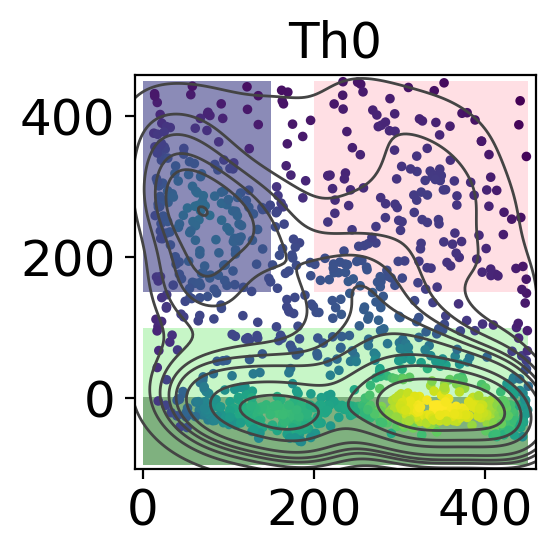

Subset to 'label_fine' == 'Th1'
cells in subset:  370


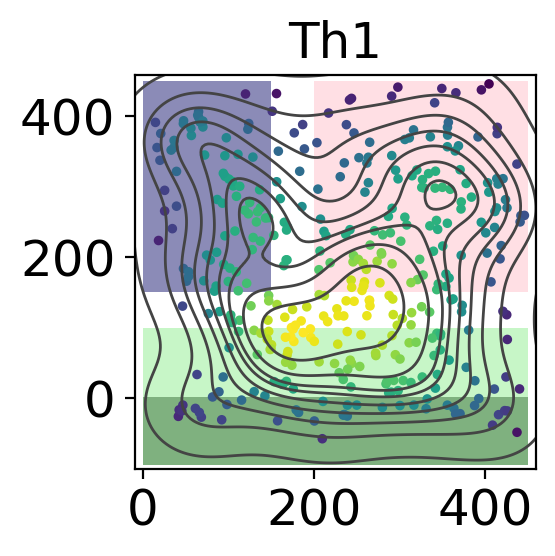

Subset to 'label_fine' == 'Th2'
cells in subset:  470


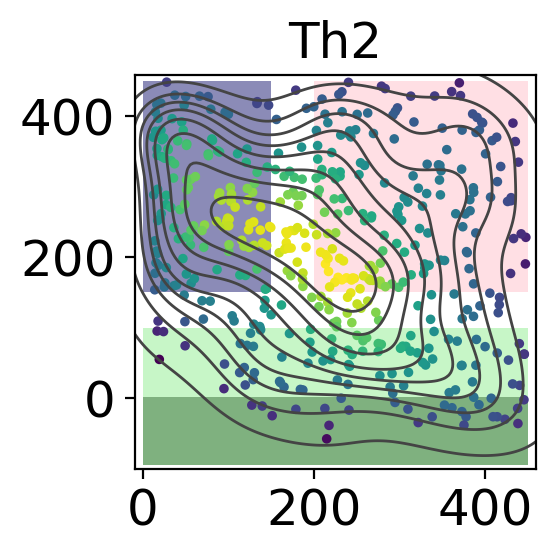

Subset to 'label_fine' == 'Th17'
cells in subset:  1732


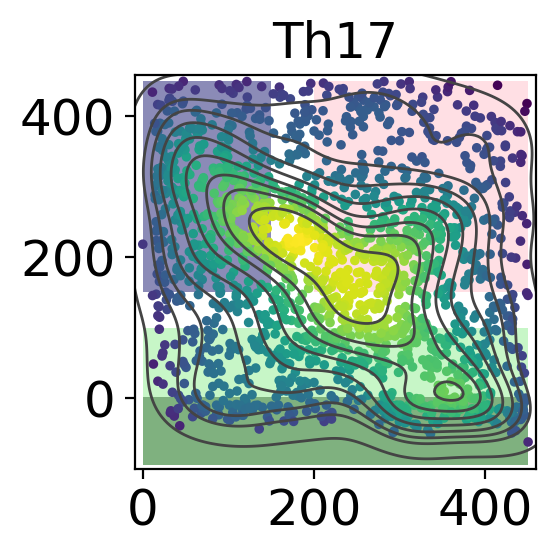

Subset to 'label_fine' == 'Treg'
cells in subset:  1153


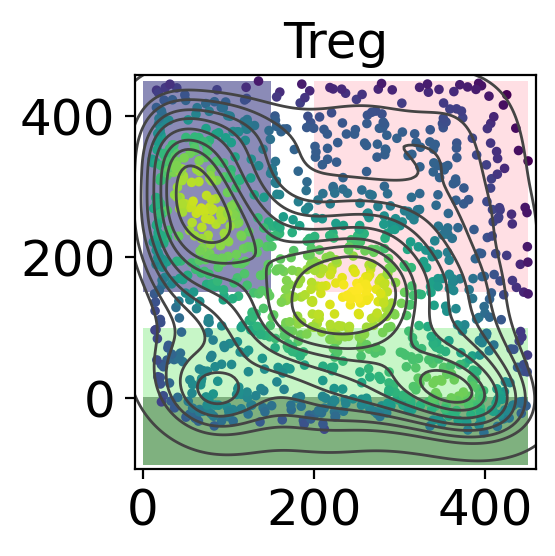

Subset to 'label_medium' == 'CD4 act'
cells in subset:  5799
Subsampling 5799 -> 5000 cells for the density


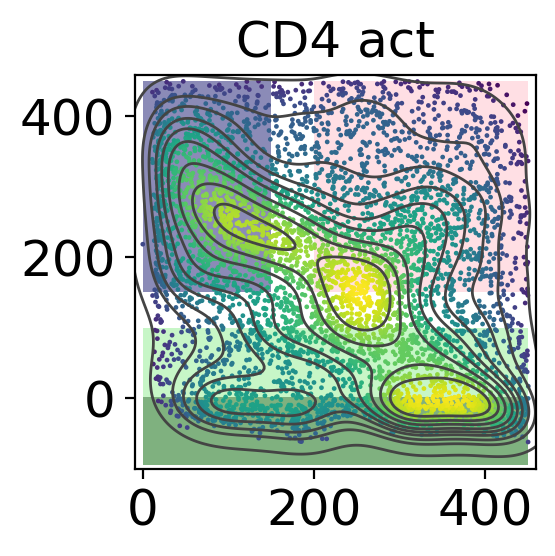

In [106]:
gates = {
    'in-TLS': {'y_min':y_min, 'y_max': 1}, # in TLS
    'near-TLS':  {'y_min': 1, 'y_max': 100}, # close to TLS (any bronchi dist)
    'near-Br': {'x_max': 150, 'y_min': 150},      # close to bronchi, far from TLS
    'far':   {'x_min': 200, 'y_min': 150},      # far from both
}
gate_palette = {
    'in-TLS': 'darkgreen', # in TLS
    'near-TLS':  'lightgreen', # close to TLS (any bronchi dist)
    'near-Br': 'midnightblue',      # close to bronchi, far from TLS
    'far':   'pink',      # far from both
}

# Plot IMAPS for CD4 subsets
celltype_col = 'label_fine'
for celltype in ['Th0', 'Th1', 'Th2', 'Th17', 'Treg']:
    p = plot_celltype_density_2d(
        adata_plot,
        sample_label=[sample_label],celltype=celltype,celltype_col=celltype_col,
        x_axis='avg_distance_to_bronchi_zone',y_axis='distance_to_tls',
        gates=gates,gate_palette=gate_palette,
        x_clip=450,y_clip=450, y_min=-100,
        point_size=24,gate_alpha = 0.5,
        max_cells=5000
    )
    plt.savefig(os.path.join(plot_out_dir, f"2D_density_{celltype}_gates_{sample_label}.pdf"), dpi=300, bbox_inches='tight', transparent=True)
    p.show()

# Plot IMAPS for all CD4s (non-naive)
celltype_col = 'label_medium'
celltype = 'CD4 act'
p = plot_celltype_density_2d(
    adata_plot,
    sample_label=[sample_label],celltype=celltype,celltype_col=celltype_col,
    x_axis='avg_distance_to_bronchi_zone',y_axis='distance_to_tls',
    gates=gates,gate_palette=gate_palette,
    x_clip=450,y_clip=450, y_min=-100,
    point_size=2,gate_alpha = 0.5,
    max_cells=5000
)
plt.savefig(os.path.join(plot_out_dir, f"2D_density_{celltype}_gates_{sample_label}.pdf"), dpi=300, bbox_inches='tight', transparent=True)
p.show()

In [107]:
sample_label = 'HDM_day30'
adata_plot = adata[adata.obs['sample_label'] == sample_label, :]
y_min = np.min(adata_plot.obs['distance_to_tls'])
print(y_min)

-123.69561128919128


Subset to 'label_fine' == 'Th0'
cells in subset:  311


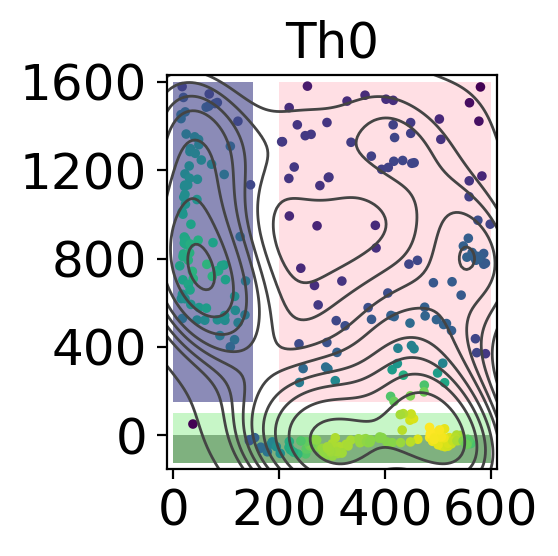

Subset to 'label_fine' == 'Th1'
cells in subset:  145


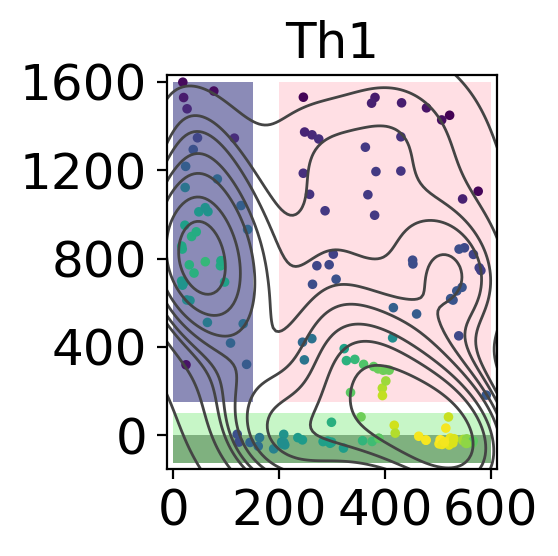

Subset to 'label_fine' == 'Th2'
cells in subset:  242


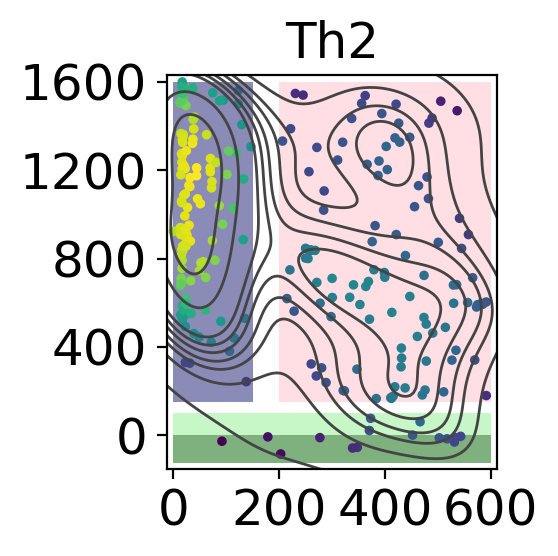

Subset to 'label_fine' == 'Th17'
cells in subset:  255


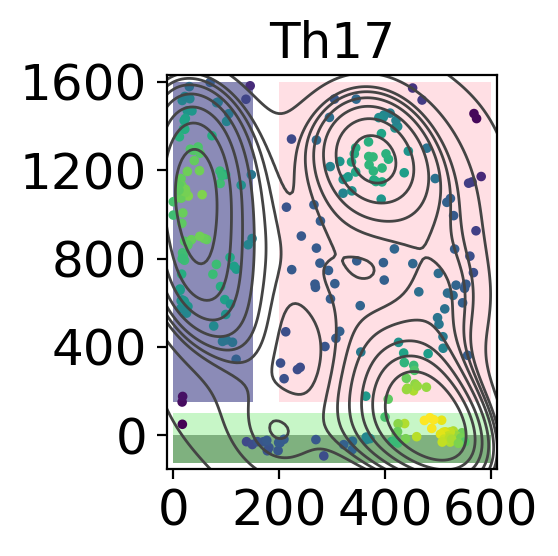

Subset to 'label_fine' == 'Treg'
cells in subset:  144


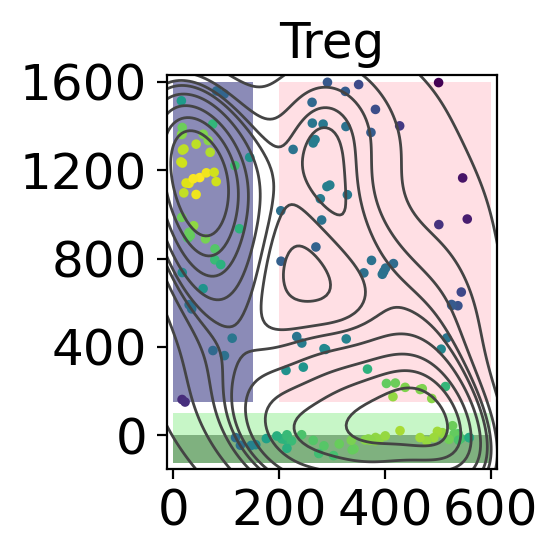

Subset to 'label_medium' == 'CD4 act'
cells in subset:  1161


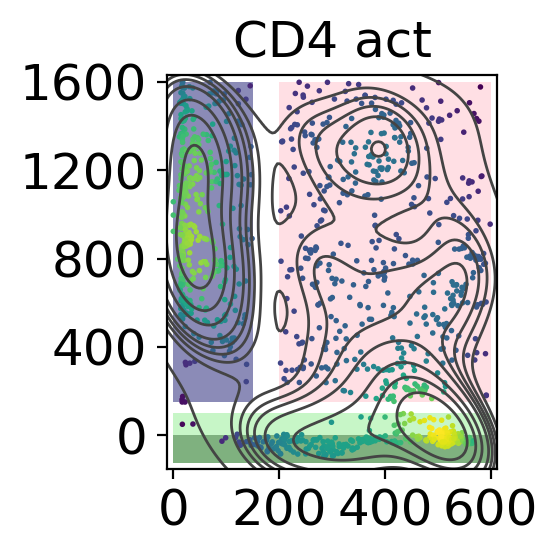

In [115]:
gates = {
    'in-TLS': {'y_min':y_min, 'y_max': 1}, # in TLS
    'near-TLS':  {'y_min': 1, 'y_max': 100}, # close to TLS (any bronchi dist)
    'near-Br': {'x_max': 150, 'y_min': 150},      # close to bronchi, far from TLS
    'far':   {'x_min': 200, 'y_min': 150},      # far from both
}
gate_palette = {
    'in-TLS': 'darkgreen', # in TLS
    'near-TLS':  'lightgreen', # close to TLS (any bronchi dist)
    'near-Br': 'midnightblue',      # close to bronchi, far from TLS
    'far':   'pink',      # far from both
}

# Plot IMAPS for CD4 subsets
celltype_col = 'label_fine'
for celltype in ['Th0', 'Th1', 'Th2', 'Th17', 'Treg']:
    p = plot_celltype_density_2d(
        adata_plot,
        sample_label=[sample_label],celltype=celltype,celltype_col=celltype_col,
        x_axis='avg_distance_to_bronchi_zone',y_axis='distance_to_tls',
        gates=gates,gate_palette=gate_palette,
                            x_clip = 600, y_clip= 1600, y_min=-150,
                        x_ticks = [0,200,400,600], y_ticks = [0, 400, 800, 1200, 1600],
        point_size=24,gate_alpha = 0.5,
        max_cells=5000
    )
    plt.savefig(os.path.join(plot_out_dir, f"2D_density_{celltype}_gates_{sample_label}.pdf"), dpi=300, bbox_inches='tight', transparent=True)
    p.show()

# Plot IMAPS for all CD4s (non-naive)
celltype_col = 'label_medium'
celltype = 'CD4 act'
p = plot_celltype_density_2d(
    adata_plot,
    sample_label=[sample_label],celltype=celltype,celltype_col=celltype_col,
    x_axis='avg_distance_to_bronchi_zone',y_axis='distance_to_tls',
    gates=gates,gate_palette=gate_palette,
    x_clip = 600, y_clip= 1600, y_min=-150,
    x_ticks = [0,200,400,600], y_ticks = [0, 400, 800, 1200, 1600],
    point_size=4,gate_alpha = 0.5,
    max_cells=5000
)
plt.savefig(os.path.join(plot_out_dir, f"2D_density_{celltype}_gates_{sample_label}.pdf"), dpi=300, bbox_inches='tight', transparent=True)
p.show()

## Plot CD4 composition of each gate 

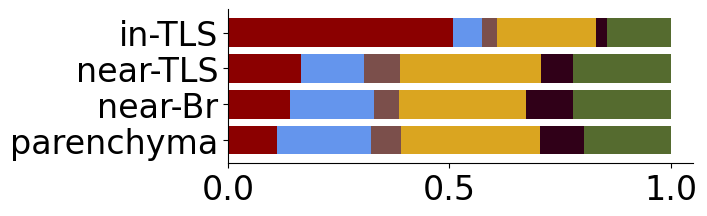

In [111]:
# cell type composition in gates
adata_plot = adata_d3[adata_d3.obs['spatial_region']!='unassigned', :]
ax1 = pu.zone_composition(adata_plot[adata_plot.obs['label_medium']=='CD4 act', :], 
                          label_col='label_fine', zone_col='spatial_region',
                       palette_map = celltype_palette_mapped,
                       plot_counts = False, 
                       zone_ncell_filter = 50,
                       horizontal=True,
                       whitespace=0.8
                      )

ax1.figure.set_size_inches(6, 2)
ax1.tick_params(axis='x', labelsize=24)
ax1.tick_params(axis='y', labelsize=24)
ax1.set_title('')       
ax1.set_xlabel('')  
ax1.legend_.remove()
plt.savefig(os.path.join(plot_out_dir, f"IMAP_gate_CD4_composition_d3.pdf"), dpi=300, bbox_inches='tight', transparent=True)

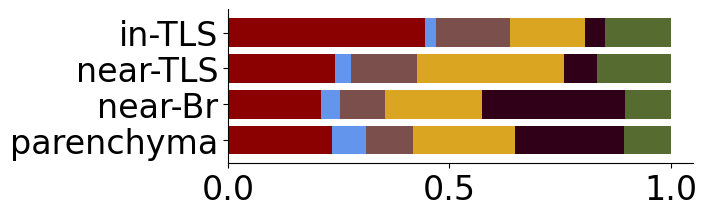

In [112]:
# cell type composition in gates
adata_plot = adata_d30[adata_d30.obs['spatial_region']!='unassigned', :]
ax1 = pu.zone_composition(adata_plot[adata_plot.obs['label_medium']=='CD4 act', :], 
                          label_col='label_fine', zone_col='spatial_region',
                       palette_map = celltype_palette_mapped,
                       plot_counts = False, 
                       zone_ncell_filter = 50,
                       horizontal=True,
                       whitespace=0.8
                      )

ax1.figure.set_size_inches(6, 2)
ax1.tick_params(axis='x', labelsize=24)
ax1.tick_params(axis='y', labelsize=24)
ax1.set_title('')       
ax1.set_xlabel('')  
ax1.legend_.remove()
plt.savefig(os.path.join(plot_out_dir, f"IMAP_gate_CD4_composition_d30.pdf"), dpi=300, bbox_inches='tight', transparent=True)

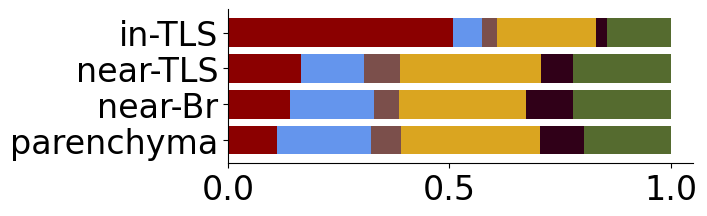

In [21]:
# cell type composition in gates
adata_plot = adata_d3[adata_d3.obs['spatial_region']!='unassigned', :]
ax1 = pu.zone_composition(adata_plot[adata_plot.obs['label_medium']=='CD4 act', :], 
                          label_col='label_fine', zone_col='spatial_region',
                            remove_unlabeled = True, 
                       palette_map = celltype_palette_mapped,
                       plot_counts = False, 
                       zone_ncell_filter = 50,
                       horizontal=True,
                       whitespace=0.8
                      )

ax1.figure.set_size_inches(6, 2)
ax1.tick_params(axis='x', labelsize=24)
ax1.tick_params(axis='y', labelsize=24)
ax1.set_title('')       
ax1.set_xlabel('')  
ax1.legend_.remove()
plt.savefig(os.path.join(plot_out_dir, f"IMAP_gate_CD4_composition.pdf"), dpi=300, bbox_inches='tight', transparent=True)

## Plot gene expression over distance to TLS and bronchi 
Plot convolved gene expression over distance using scVelo plotting.

In [22]:
# matplotlib settings
plt.rcdefaults()
mpl.rcParams['pdf.fonttype'] = 42

In [134]:
# Filter genes by those robustly expressed in CITE dataset and in Xenium datast (5% threshold in at least one subset):
# CITE genes expressed in 5% of at least one subset
gene_df = pd.read_csv(os.path.join(BASE_OUTDIR, 'cell_labeling/ouputs_mouselung_hurskainen_ref_consolidate_labels_xenseg_HDM/cite_integration/cite_expressed_genes_by_annotation.csv'))
genes_cite_filt = gene_df['x'].tolist()

# Xenium genes expressed in 5% of at least one subset
genes_xen_filt = []
# adata_cd4 = adata.copy()
adata_cd4 = adata[adata.obs['label_coarse']=='CD4 T cell', :].copy()
for subset in adata_cd4.obs['label_fine'].unique().tolist():
    adata_cd4_subset = adata_cd4[adata_cd4.obs['label_fine'] == subset, :]
    adata_cd4_subset = du.filter_adata_expressed_in_n_cells(adata_cd4_subset, fraction=0.05)
    genes_xen_filt.extend(adata_cd4_subset.var.index.tolist())
genes_xen_filt = list(set(genes_xen_filt))

# take the intersection and use this list for heatmaps 
genes_cite_xen_filt = list(set(genes_cite_filt) & set(genes_xen_filt))

In [135]:
genes_highlight_tls = ['Il21', 'Ccr7', 'Slamf6', 'Tcf7', 'Id3', 'Tbx21', 'Cxcr6', 'Il1rl1', 'Gata3', 'Il13', 'Calca']
genes_highlight_bronchi = ['Il1rl1', 'Il2ra', 'Foxp3', 'Gata3', 'Klrg1', 'Nmur1', 'Prdm1', 'Cxcr6', 'Id3', 'Slamf6', 'Tcf7', 'Tbx21', 'Ccr7']

HDM_day3
Creating Heatmap for sample labels  HDM_day3
Subset to 'label_medium'=='CD4 act'
adata shape:  (8658, 180)
clipping x to  450
max value before clip  1650.777859359595
Setting `n_convolve` to 1353 (5 bins, 6765 cells) 
HDM_day30
Creating Heatmap for sample labels  HDM_day30
Subset to 'label_medium'=='CD4 act'
adata shape:  (1828, 180)
clipping x to  450
max value before clip  3008.922276714983
Setting `n_convolve` to 93 (5 bins, 469 cells) 


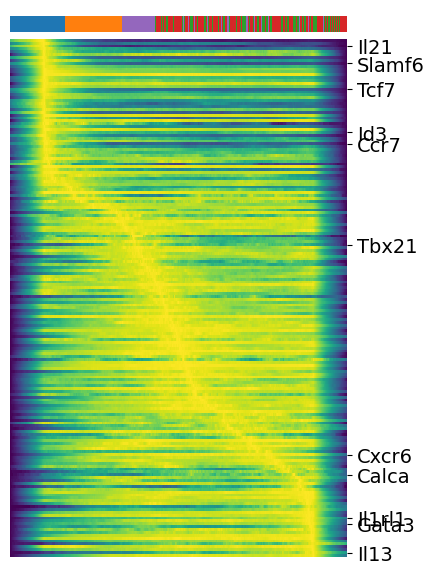

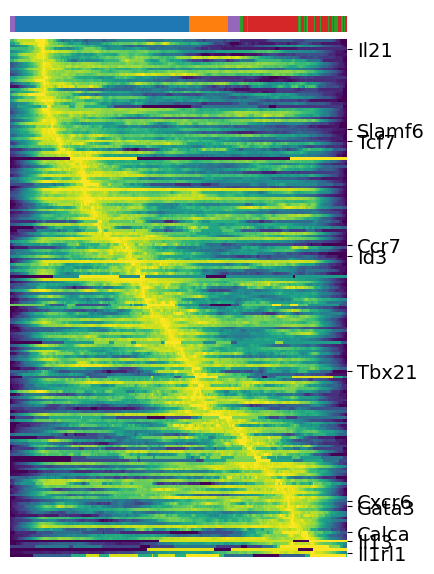

In [136]:
for sample_label in adata.obs['sample_label'].cat.categories:
    print(sample_label)
    adata_plot = adata[adata.obs['sample_label']==sample_label, :]
    s = scvelo_heatmap(
        adata_plot[:,genes_cite_xen_filt],
        sample_label=[sample_label],
        sortby = 'distance_to_tls',
        key_name = 'label_medium',
        key_value = 'CD4 act',
        highlight = genes_highlight_tls,
        x_clip = 450, 
        expression_threshold= None, # already using a filtered gene list 
        figsize=(5,6)
    )
    s
    # plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls-structure_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)

HDM_day3
Creating Heatmap for sample labels  HDM_day3
Subset to 'label_medium'=='CD4 act'
adata shape:  (7458, 180)
clipping x to  450
max value before clip  1718.5338247556192
Setting `n_convolve` to 1166 (5 bins, 5830 cells) 
HDM_day30
Creating Heatmap for sample labels  HDM_day30
Subset to 'label_medium'=='CD4 act'
adata shape:  (1549, 180)
clipping x to  450
max value before clip  1323.009737176856
Setting `n_convolve` to 216 (5 bins, 1083 cells) 


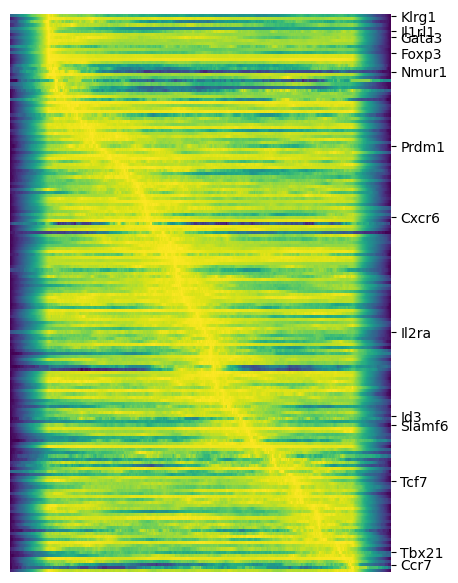

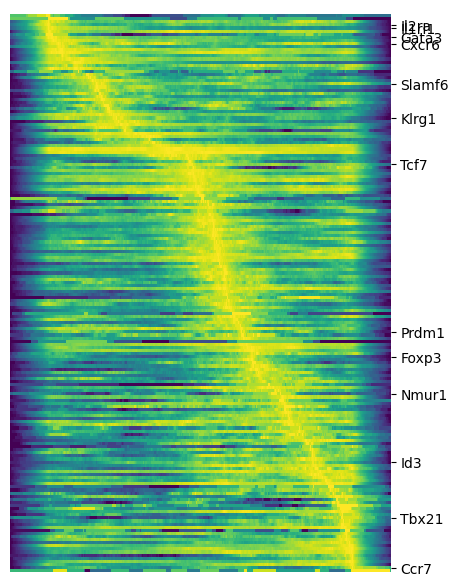

In [26]:
for sample_label in adata.obs['sample_label'].cat.categories:
    print(sample_label)
    adata_plot = adata[adata.obs['sample_label']==sample_label, :]
    s = scvelo_heatmap(
        adata_plot[~adata_plot.obs['zone_consol'].isin(['TLS']),genes_cite_xen_filt],
        sample_label=[sample_label],
        sortby = 'avg_distance_to_bronchi_zone',
        key_name = 'label_medium',
        key_value = 'CD4 act',
        highlight = genes_highlight_bronchi,
        x_clip = 450, 
        expression_threshold= None, # already using a filtered gene list 
        figsize=(5,6)
    )
    s
    plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_bronchi-zone_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)

## Ligand–receptor spatial co-localization (Jensen-Shannon distance)

In [29]:
from scipy.spatial.distance import jensenshannon


def _gene_expr(ad, gene, layer=None):
    """1D expression vector for a single gene (handles sparse / layer)."""
    X = ad[:, gene].layers[layer] if layer is not None else ad[:, gene].X
    return (X.toarray() if hasattr(X, 'toarray') else np.asarray(X)).ravel()


def _spatial_field(x, y, w, xedges, yedges, sigma):
    """2D summed-expression grid per bin, optionally Gaussian-smoothed.
    This is the binned data that (after normalization) feeds the JS distance."""
    w = np.clip(np.nan_to_num(w), 0, None)
    H, _, _ = np.histogram2d(x, y, bins=[xedges, yedges], weights=w)
    if sigma:
        H = gaussian_filter(H, sigma=sigma)
    return H


def _normalize(H):
    """Flatten a 2D field to a probability vector (sum 1); None if empty."""
    if H is None:
        return None
    s = H.sum()
    return None if s <= 0 else (H / s).ravel()


def plot_binned_fields(fields, receptor, ligands, celltypes,
                       ncols=4, panel_size=2.2, cmap='viridis'):
    """Diagnostic: spatial maps of the binned summed expression that go into the
    JS calculation -- one panel per ligand (all cells) and one per receptor x
    cell type. Each panel is scaled to its own 99th percentile."""
    xedges, yedges = fields['xedges'], fields['yedges']
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    panels = [(f'ligand: {lig}', fields['ligands'][lig]) for lig in ligands]
    panels += [(f'{receptor} in {ct}', fields['receptors'][ct]) for ct in celltypes]

    n = len(panels)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, dpi=150, squeeze=False,
                             figsize=(panel_size * ncols, panel_size * nrows))
    for ax in axes.ravel():
        ax.axis('off')
    for k, (title, grid) in enumerate(panels):
        ax = axes.ravel()[k]
        ax.axis('on')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title, fontsize=7)
        if grid is None or not np.any(grid > 0):
            ax.text(0.5, 0.5, 'no signal', ha='center', va='center',
                    fontsize=8, transform=ax.transAxes)
            continue
        vmax = np.percentile(grid[grid > 0], 99)
        ax.imshow(grid.T, origin='lower', extent=extent, aspect='equal',
                  cmap=cmap, vmax=vmax)
    fig.suptitle(f"Binned summed expression (JS inputs) — {fields['sample']}",
                 fontsize=10)
    fig.tight_layout()
    return fig


def plot_ligand_receptor_js_proximity(
    adata, receptor, ligands, celltype_col, celltypes,
    sample='HDM_day3', sample_col='sample_label',
    bin_size_um=50, smooth_sigma=1.0,
    x_coord='x_centroid', y_coord='y_centroid',
    layer=None, cmap='viridis_r', annotate=False, figsize=None,
    show_binned=False, vmin=None, vmax=None, autoscale=False,
):
    """
    Spatial co-localization of ligand-producing cells and receptor+ cells, per
    cell type. One receptor (-> top bar) and its ligand(s) (-> rows) vs. an
    ordered list of cell types (-> columns).

    Each heatmap cell compares (a) the spatial distribution of the ligand's
    expression over ALL cells and (b) the spatial distribution of `receptor`
    expression within that column's cell type. Both are sum-per-bin histograms
    on a shared `bin_size_um` grid over (x_coord, y_coord), Gaussian-smoothed.

    Distances are Jensen-Shannon distance in [0, 1]; bin-independent (ignores
    how far apart non-overlapping bins are; the smoothing is what gives it any
    neighbor-awareness). 0 = co-localized; with cmap='viridis_r', bright =
    co-localized.

    Set show_binned=True to also plot the binned summed-expression maps. Returns
    (fig, M, fields): M = [ligand x celltype] distance matrix; fields = dict of
    the 2D binned grids (+ grid edges) for replotting.
    """
    missing = [g for g in [receptor, *ligands] if g not in adata.var_names]
    if missing:
        raise ValueError(f'genes not in adata.var_names: {missing}')

    ad = adata[adata.obs[sample_col] == sample]
    x_all = ad.obs[x_coord].to_numpy(dtype=float)
    y_all = ad.obs[y_coord].to_numpy(dtype=float)

    # shared grid edges from all cells in the sample
    xedges = np.arange(x_all.min(), x_all.max() + bin_size_um, bin_size_um)
    yedges = np.arange(y_all.min(), y_all.max() + bin_size_um, bin_size_um)

    # ligand fields (all cells), one per row
    lig_fields = {lig: _spatial_field(x_all, y_all, _gene_expr(ad, lig, layer),
                                      xedges, yedges, smooth_sigma)
                  for lig in ligands}

    # receptor field per cell type (column) + mean receptor expression
    rec_all = _gene_expr(ad, receptor, layer)
    rec_fields, mean_recep = {}, {}
    for ct in celltypes:
        mask = (ad.obs[celltype_col] == ct).to_numpy()
        if mask.sum() == 0:
            rec_fields[ct], mean_recep[ct] = None, np.nan
            continue
        rec_fields[ct] = _spatial_field(x_all[mask], y_all[mask], rec_all[mask],
                                        xedges, yedges, smooth_sigma)
        mean_recep[ct] = rec_all[mask].mean()

    fields = {'ligands': lig_fields, 'receptors': rec_fields,
              'xedges': xedges, 'yedges': yedges,
              'bin_size_um': bin_size_um, 'sample': sample}

    # distance matrix [ligand x celltype]
    P = {lig: _normalize(lig_fields[lig]) for lig in ligands}
    Q = {ct: _normalize(rec_fields[ct]) for ct in celltypes}
    M = np.full((len(ligands), len(celltypes)), np.nan)
    for i, lig in enumerate(ligands):
        for j, ct in enumerate(celltypes):
            if P[lig] is not None and Q[ct] is not None:
                M[i, j] = jensenshannon(P[lig], Q[ct], base=2)

    # color range / labels
    finite = M[np.isfinite(M)]
    if autoscale:
        # stretch the colormap over the actual min..max of the computed values
        vmin = float(finite.min()) if finite.size else 0.0
        vmax = float(finite.max()) if finite.size else 1.0
        if vmax <= vmin:                 # guard against a flat/degenerate range
            vmax = vmin + 1e-9
    else:
        if vmin is None:
            vmin = 0.0
        if vmax is None:
            vmax = 1.0

    cbar_label = 'J-S distance\n(0 = co-localized)'
    fmt = '{:.2f}'

    # ---- main heatmap + receptor bar ----
    n_row, n_col = len(ligands), len(celltypes)

    # Fixed-geometry layout (explicit inches) so every heatmap cell is square and
    # the receptor bar plot is exactly two cell-heights tall. Axes are placed by
    # hand (fig.add_axes) rather than via a gridspec so the bar, heatmap and
    # colorbar share the same left edge / width and align exactly.
    BAR_CELLS = 2.0                      # bar height = this many heatmap cells
    L, R, T, B = 1.2, 0.10, 0.10, 1.6    # figure margins (in): y-labels / x-labels
    GAP, CBAR_W, HSP = 0.12, 0.16, 0.06  # hm->cbar gap, colorbar width, bar->hm gap

    if figsize is None:
        cell = 0.4                       # default heatmap cell size (in)
        fig_w = L + n_col * cell + GAP + CBAR_W + R
        fig_h = B + (n_row + BAR_CELLS) * cell + HSP + T
    else:
        fig_w, fig_h = figsize
        # largest square cell that fits the requested figure size
        cell = min((fig_w - L - GAP - CBAR_W - R) / n_col,
                   (fig_h - B - HSP - T) / (n_row + BAR_CELLS))

    hm_w, hm_h = n_col * cell, n_row * cell
    bar_h = BAR_CELLS * cell

    fig = plt.figure(figsize=(fig_w, fig_h), dpi=150)
    ax_hm = fig.add_axes([L / fig_w, B / fig_h, hm_w / fig_w, hm_h / fig_h])
    ax_bar = fig.add_axes([L / fig_w, (B + hm_h + HSP) / fig_h,
                           hm_w / fig_w, bar_h / fig_h])
    cax = fig.add_axes([(L + hm_w + GAP) / fig_w, B / fig_h,
                        CBAR_W / fig_w, hm_h / fig_h])

    # receptor expression bar: ylim set so the tallest bar fills the axes, i.e.
    # the max bar height equals bar_h = two heatmap cells.
    bar_vals = np.array([mean_recep[ct] for ct in celltypes], dtype=float)
    ax_bar.bar(np.arange(n_col), bar_vals, color='0.4', width=0.8)
    bar_top = np.nanmax(bar_vals) if np.isfinite(bar_vals).any() else 1.0
    ax_bar.set_ylim(0, bar_top if bar_top > 0 else 1.0)
    ax_bar.set_xlim(-0.5, n_col - 0.5)
    ax_bar.tick_params(labelbottom=False)
    ax_bar.spines[['top', 'right']].set_visible(False)

    cmap_obj = (cmap if isinstance(cmap, mcolors.Colormap)
                else plt.get_cmap(cmap)).copy()
    cmap_obj.set_bad('lightgray')
    # aspect='auto' fills the square-proportioned axes box -> square cells
    im = ax_hm.imshow(np.ma.masked_invalid(M), aspect='auto', cmap=cmap_obj,
                      vmin=vmin, vmax=vmax)
    ax_hm.set_xticks(np.arange(n_col))
    ax_hm.set_xticklabels(celltypes, rotation=90)
    ax_hm.set_yticks(np.arange(n_row))
    ax_hm.set_yticklabels(ligands)
    ax_hm.set_xlim(-0.5, n_col - 0.5)

    if annotate:
        for i in range(n_row):
            for j in range(n_col):
                if not np.isnan(M[i, j]):
                    ax_hm.text(j, i, fmt.format(M[i, j]), ha='center', va='center',
                               fontsize=6, color='black')

    cb = fig.colorbar(im, cax=cax)
    # colorbar ticks every 0.1, aligned to multiples of 0.1 within the range
    tick0 = np.ceil(vmin / 0.1) * 0.1
    cb.set_ticks(np.round(np.arange(tick0, vmax + 1e-9, 0.1), 1))

    if show_binned:
        plot_binned_fields(fields, receptor, ligands, celltypes)

    return fig, M, fields

In [30]:
import re


def _parse_lr(name2):
    """Parse CellChatDB `interaction_name_2` (e.g. 'Tgfb1 - (Tgfbr1+Tgfbr2)')
    into (ligand_genes, receptor_genes) gene-symbol lists. None if unparseable."""
    parts = re.split(r'\s+-\s+', str(name2), maxsplit=1)
    if len(parts) != 2:
        return None
    def genes(s):
        return [g.strip() for g in s.strip().strip('()').split('+') if g.strip()]
    return genes(parts[0]), genes(parts[1])


def rank_lr_js_delta(
    adata, df_lr, celltypes, celltype_col='label_fine',
    sample='HDM_day3', sample_col='sample_label',
    bin_size_um=50, smooth_sigma=1.0,
    x_coord='x_centroid', y_coord='y_centroid',
    min_frac_pos=0.05, layer=None,
):
    """
    For every single-gene-ligand x single-receptor pair, compute the JS
    co-localization distance between the ligand's spatial field (all cells) and
    the receptor's spatial field within each of two cell types, then the signed
    delta.

    Pairs are parsed from `interaction_name_2`. Ligands are kept only if they are
    single genes. Multi-subunit RECEPTOR complexes are EXPANDED: each subunit
    becomes its own (ligand, receptor) pair, tested independently (no co-expression
    requirement). Gene matching to adata.var_names is case-insensitive.

    celltypes : [A, B]
        delta = JS_A - JS_B. Since low JS = co-localized, delta > 0 => the pair is
        MORE co-localized with B than A. (e.g. ['Th0','Th2']: delta>0 = more
        co-localized with Th2.)
    min_frac_pos : float
        Keep a pair only if the receptor is detected (expr > 0) in >= this
        fraction of cells in AT LEAST ONE of the two cell types.

    Returns a DataFrame sorted by delta (desc), with JS_A/JS_B, delta, receptor
    %positive and mean expression per cell type, ligand mean expression, and
    per-cell-type cell counts.
    """
    if len(celltypes) != 2:
        raise ValueError('celltypes must be exactly two: [A, B]')
    ca, cb = celltypes

    # case-insensitive resolver: lowercased symbol -> canonical var name
    var_lower = {v.lower(): v for v in adata.var_names}
    def _resolve(g):
        return var_lower.get(g.lower())

    # build pairs: single-gene ligand x each receptor subunit (dedup, canonical names)
    pairs, seen = [], set()
    for name2 in df_lr['interaction_name_2'].dropna():
        parsed = _parse_lr(name2)
        if parsed is None:
            continue
        ligs, recs = parsed
        if len(ligs) != 1:                       # single-gene ligands only
            continue
        lig = _resolve(ligs[0])
        if lig is None:
            continue
        for rec_raw in recs:                     # expand: one pair per receptor subunit
            rec = _resolve(rec_raw)
            if rec is not None and (lig, rec) not in seen:
                seen.add((lig, rec)); pairs.append((lig, rec))
    if not pairs:
        raise ValueError('no ligand-receptor pairs with both genes in adata.var_names')

    ad = adata[adata.obs[sample_col] == sample]
    x_all = ad.obs[x_coord].to_numpy(float)
    y_all = ad.obs[y_coord].to_numpy(float)
    xedges = np.arange(x_all.min(), x_all.max() + bin_size_um, bin_size_um)
    yedges = np.arange(y_all.min(), y_all.max() + bin_size_um, bin_size_um)

    masks = {c: (ad.obs[celltype_col] == c).to_numpy() for c in (ca, cb)}
    n_cells = {c: int(masks[c].sum()) for c in (ca, cb)}

    # ligand fields (all cells), cached per unique ligand
    lig_norm, mean_lig = {}, {}
    for lig in {p[0] for p in pairs}:
        e = _gene_expr(ad, lig, layer)
        lig_norm[lig] = _normalize(_spatial_field(x_all, y_all, e, xedges, yedges, smooth_sigma))
        mean_lig[lig] = float(e.mean())

    # receptor fields per (receptor, cell type), cached
    rec_norm, rec_stats = {}, {}
    for rec in {p[1] for p in pairs}:
        e_all = _gene_expr(ad, rec, layer)
        for c in (ca, cb):
            m = masks[c]
            if m.sum() == 0:
                rec_norm[(rec, c)], rec_stats[(rec, c)] = None, (0.0, np.nan)
                continue
            ec = e_all[m]
            rec_stats[(rec, c)] = (float((ec > 0).mean()), float(ec.mean()))
            rec_norm[(rec, c)] = _normalize(
                _spatial_field(x_all[m], y_all[m], ec, xedges, yedges, smooth_sigma))

    rows = []
    for lig, rec in pairs:
        fa, fb = rec_stats[(rec, ca)][0], rec_stats[(rec, cb)][0]
        if max(fa, fb) < min_frac_pos:          # receptor floor (receptor only)
            continue
        L, Pa, Pb = lig_norm[lig], rec_norm[(rec, ca)], rec_norm[(rec, cb)]
        if L is None or Pa is None or Pb is None:
            continue
        js_a = jensenshannon(L, Pa, base=2)
        js_b = jensenshannon(L, Pb, base=2)
        rows.append({
            'ligand': lig, 'receptor': rec,
            f'JS_{ca}': js_a, f'JS_{cb}': js_b, 'delta': js_a - js_b,
            f'frac_pos_{ca}': fa, f'frac_pos_{cb}': fb,
            f'mean_recep_{ca}': rec_stats[(rec, ca)][1],
            f'mean_recep_{cb}': rec_stats[(rec, cb)][1],
            'mean_lig': mean_lig[lig],
            f'n_{ca}': n_cells[ca], f'n_{cb}': n_cells[cb],
        })

    res = pd.DataFrame(rows)
    if len(res):
        res = res.sort_values('delta', ascending=False).reset_index(drop=True)
    return res



# import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_js_delta_jitter(
    res,
    top_n=5,
    pairs_to_label=None,
    delta_col="delta",
    label_cols=("ligand", "receptor"),
    pos_color="firebrick",
    neg_color="midnightblue",
    figsize=(3.2, 5),
    jitter=0.08,
    point_size=14,
    label_fontsize=12,
    random_state=0,
    title=None,
):
    """Jitter plot of ΔJS per ligand-receptor pair (one point each), y = delta.

    Labels either the top/bottom n or specific user-defined pairs.

    Parameters:
    -----------
    res : pd.DataFrame
        Results dataframe containing delta scores.
    top_n : int
        Number of top positive and top negative pairs to label (ignored if
        pairs_to_label is set).
    pairs_to_label : list of tuples, optional
        Specific pairs to label, e.g. [('Tgfb1', 'Tgfbr1'), ('Il4', 'Il4r')].
    pos_color : str
        Color for points with positive delta (e.g. enriched in condition B /
        Th2).
    neg_color : str
        Color for points with negative delta (e.g. enriched in condition A /
        Th0).
    """
    d = res.dropna(subset=[delta_col]).copy()
    y = d[delta_col].to_numpy()
    rng = np.random.default_rng(random_state)
    x = rng.uniform(-jitter, jitter, len(y))

    # Fix 1: Store jitter coordinates back into the dataframe to avoid duplicate/misaligned plotting
    d["x_jitter"] = x

    ymin, ymax = y.min(), y.max()
    pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
    ylo, yhi = ymin - pad, ymax + pad
    min_gap = (yhi - ylo) / 30.0

    def _declutter(t, gap, lo, hi):
        t = np.asarray(t, float)
        if len(t) == 0:
            return t
        idx = np.argsort(t)
        ys = t[idx].copy()
        for i in range(1, len(ys)):
            if ys[i] - ys[i - 1] < gap:
                ys[i] = ys[i - 1] + gap
        ys += t.mean() - ys.mean()
        if ys[-1] > hi:
            ys -= ys[-1] - hi
        if ys[0] < lo:
            ys -= ys[0] - lo
        out = np.empty_like(ys)
        out[idx] = ys
        return out

    fig, ax = plt.subplots(figsize=figsize, dpi=150)

    # Plot the background points
    ax.scatter(
        x, y, s=point_size, color="0.6", alpha=0.4, edgecolors="none", zorder=1
    )

    lc0, lc1 = label_cols

    # Fix 2: Handle custom pair inputs vs top_n defaults
    if pairs_to_label is not None:
        # Map user input to match the structure format
        pairs_set = set(pairs_to_label)
        mask = d.apply(lambda row: (row[lc0], row[lc1]) in pairs_set, axis=1)
        selected = d[mask]

        # Divide custom list into positive and negative groups
        top = selected[selected[delta_col] >= 0].sort_values(
            delta_col, ascending=False
        )
        bot = selected[selected[delta_col] < 0].sort_values(
            delta_col, ascending=True
        )
    else:
        d_sorted = d.sort_values(delta_col, ascending=False)
        top = d_sorted.head(top_n)
        bot = d_sorted.tail(top_n)
        bot = bot[~bot.index.isin(top.index)]  # avoid overlap on tiny tables

    lx = jitter + 0.05

    # Fix 3: Highlight groups utilizing independent directional color variables
    for grp, col in [(top, pos_color), (bot, neg_color)]:
        if len(grp) == 0:
            continue

        # Plot overlay points directly at their exact pre-calculated jitter coordinate
        ax.scatter(
            grp["x_jitter"],
            grp[delta_col],
            s=point_size + 10,
            color=col,
            zorder=2,
        )

        ly = _declutter(grp[delta_col].to_numpy(), min_gap, ylo, yhi)
        for (_, row), yl in zip(grp.iterrows(), ly):
            ax.annotate(
                f"{row[lc0]}\u2192{row[lc1]}",
                xy=(row["x_jitter"], row[delta_col]),
                xytext=(lx, yl),
                fontsize=label_fontsize,
                va="center",
                ha="left",
                arrowprops=dict(arrowstyle="-", lw=0.4, color="0.6"),
            )

    ax.axhline(0, color="black", lw=0.8, ls="--", zorder=0)
    ax.set_xticks([])
    ax.set_xlim(-0.4, 1.6)
    ax.set_ylim(ylo, yhi)
    ax.set_ylabel(
        "Δ JS distance ("
        + "−".join(c[3:] for c in res.columns if c.startswith("JS_"))
        + ")"
    )
    ax.spines[["top", 'right', "bottom"]].set_visible(False)

    if title:
        ax.set_title(title, fontsize=10)
    fig.tight_layout()

    return fig, ax

In [129]:
# def plot_js_delta_bar(
#     res,
#     top_n=None,
#     pairs_to_label=None,
#     delta_col="delta",
#     label_cols=("ligand", "receptor"),
#     pos_color="firebrick",
#     neg_color="midnightblue",
#     bg_color="0.8",
#     figsize=(4, 6),
#     bar_height=0.8,
#     label_fontsize=12,
#     title=None,
# ):
#     """Horizontal bar plot of ΔJS per ligand-receptor pair (one bar each).

#     ALL pairs are shown as bars, ordered from highest positive delta (top) to
#     most negative (bottom). Only the highlighted pairs are colored by sign
#     (pos_color for delta >= 0, neg_color for delta < 0) and given a y-axis label
#     -- matching the coloring scheme of `plot_js_delta_jitter`; every other bar is
#     drawn in `bg_color` and left unlabeled.

#     Highlighted pairs are those listed in `pairs_to_label`, or -- if that is None
#     -- the top_n most positive and top_n most negative pairs. If both are None,
#     no bars are highlighted (all bars are bg_color).

#     Parameters
#     ----------
#     res : pd.DataFrame
#         Results dataframe containing delta scores (e.g. from rank_lr_js_delta).
#     top_n : int, optional
#         Highlight the top_n most positive and top_n most negative pairs
#         (ignored if pairs_to_label is set).
#     pairs_to_label : list of tuples, optional
#         Specific pairs to highlight, e.g. [('Tgfb1', 'Tgfbr1'), ('Il4', 'Il4r')].
#     pos_color : str
#         Color for highlighted bars with positive delta (e.g. enriched in
#         condition B / Th2).
#     neg_color : str
#         Color for highlighted bars with negative delta (e.g. enriched in
#         condition A / Th0).
#     bg_color : str
#         Color for the non-highlighted (background) bars.
#     """
#     d = res.dropna(subset=[delta_col]).copy()
#     lc0, lc1 = label_cols

#     # order highest positive -> most negative (invert_yaxis puts the top of the
#     # sorted list at the top of the plot)
#     d = d.sort_values(delta_col, ascending=False).reset_index(drop=True)

#     # decide which pairs to highlight (all other bars stay bg_color)
#     if pairs_to_label is not None:
#         pairs_set = set(pairs_to_label)
#         highlight = d.apply(
#             lambda row: (row[lc0], row[lc1]) in pairs_set, axis=1
#         ).to_numpy()
#     elif top_n is not None:
#         highlight = np.zeros(len(d), dtype=bool)
#         highlight[:top_n] = True            # top_n most positive
#         highlight[len(d) - top_n:] = True   # top_n most negative
#     else:
#         highlight = np.zeros(len(d), dtype=bool)

#     labels = (d[lc0].astype(str) + "→" + d[lc1].astype(str)).to_numpy()
#     vals = d[delta_col].to_numpy()
#     colors = [
#         (pos_color if v >= 0 else neg_color) if h else bg_color
#         for v, h in zip(vals, highlight)
#     ]
#     y = np.arange(len(d))

#     fig, ax = plt.subplots(figsize=figsize, dpi=150)
#     ax.barh(y, vals, height=bar_height, color=colors, zorder=2)

#     ax.axvline(0, color="black", lw=0.8, ls="--", zorder=1)

#     # label only the highlighted bars (labeling every pair would be unreadable)
#     hl = np.where(highlight)[0]
#     ax.set_yticks(y[hl])
#     ax.set_yticklabels(labels[hl], fontsize=label_fontsize)

#     ax.invert_yaxis()  # highest positive delta at the top
#     ax.set_xlabel(
#         "Δ JS distance ("
#         + "−".join(c[3:] for c in res.columns if c.startswith("JS_"))
#         + ")"
#     )
#     ax.spines[["top", "right"]].set_visible(False)

#     if title:
#         ax.set_title(title, fontsize=10)
#     fig.tight_layout()

#     return fig, ax


### Rank ligand–receptor pairs by ΔJS between two cell types: day 3

In [31]:
df_lr = pd.read_csv(os.path.join(inputs_dir, 'interaction_input_CellChatDB.csv'))

res = rank_lr_js_delta(
    adata, df_lr,
    celltypes=['Th2','Th0'],      # delta = JS_Th2 - JS_Th0  (>0 = more co-localized with Th0)
    celltype_col='label_fine',
    sample='HDM_day3',
    bin_size_um=50, smooth_sigma=1.0,
    min_frac_pos=0.10,
)

In [44]:
res.to_csv('d3_deltaJS_Th2-Th0.csv')

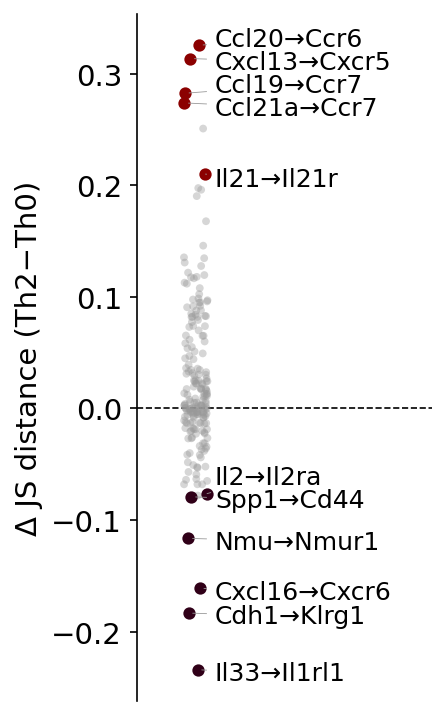

In [49]:
fig, ax = plot_js_delta_jitter(res, 
                               pairs_to_label=[('Ccl19', 'Ccr7'), ('Ccl21a', 'Ccr7'), ('Cxcl13','Cxcr5'), ('Il21', 'Il21r'), ('Ccl20', 'Ccr6'),
                                              ('Cxcl16', 'Cxcr6'), ('Il33','Il1rl1'), ('Cdh1', 'Klrg1'), ('Nmu','Nmur1'), ('Spp1', 'Cd44'), ('Il2', 'Il2ra')],
                               pos_color='darkred', neg_color = '#300018')
plt.savefig(os.path.join(plot_out_dir, f"HDM_day3_deltaJS_Th0_Th2_jitter.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [128]:
# fig, ax = plot_js_delta_bar(res, 
#                                pairs_to_label=[('Ccl19', 'Ccr7'), ('Ccl21a', 'Ccr7'), ('Cxcl13','Cxcr5'), ('Il21', 'Il21r'), ('Ccl20', 'Ccr6'),
#                                               ('Cxcl16', 'Cxcr6'), ('Il33','Il1rl1'), ('Cdh1', 'Klrg1'), ('Nmu','Nmur1'), ('Spp1', 'Cd44'), ('Il2', 'Il2ra')],
#                                pos_color='darkred', neg_color = '#300018')
# # plt.savefig(os.path.join(plot_out_dir, f"HDM_day3_deltaJS_Th0_Th2_bar.pdf"), dpi=300, bbox_inches='tight', transparent=True)
# plt.show()

### Plot JS distance and receptor expression for LR pairs with largest difference between Th0 and Th2: day 3

In [33]:
celltypes = ['Th0', 'Th1', 'Th2', 'Th17', 'Treg']

#### Higher co-localization in Th0

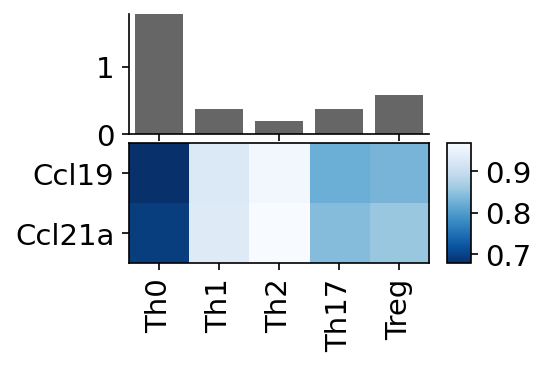

In [34]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Ccr7',
    ligands=['Ccl19', 'Ccl21a'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day3',
    autoscale=True,
    bin_size_um=50,
    cmap='Blues_r',     
)
plt.savefig(os.path.join(plot_out_dir, f"HDM_day3_JSdist_Ccr7_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

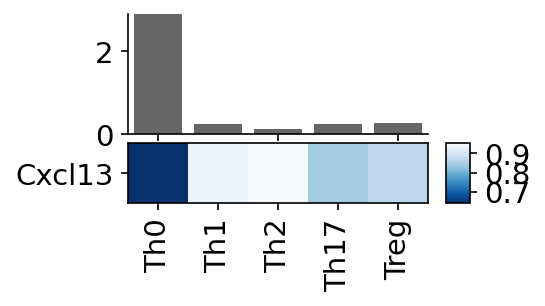

In [35]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Cxcr5',
    ligands=['Cxcl13'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day3',
    autoscale=True,
    bin_size_um=50,
    cmap='Blues_r',     
)
plt.savefig(os.path.join(plot_out_dir, f"HDM_day3_JSdist_Cxcr5_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

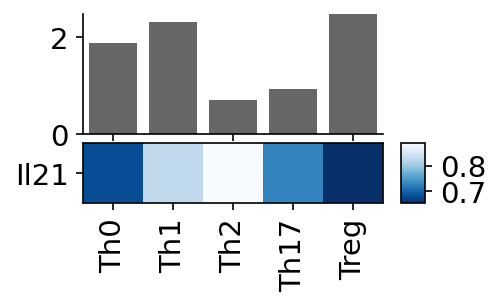

In [36]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Il21r',
    ligands=['Il21'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day3',
    autoscale=True,
    bin_size_um=50,
    cmap='Blues_r',     
)
plt.savefig(os.path.join(plot_out_dir, f"HDM_day3_JSdist_Il21r_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

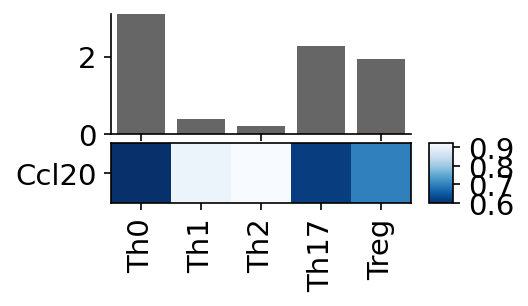

In [37]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Ccr6',
    ligands=['Ccl20'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day3',
    # vmin = 0.5,
    autoscale=True,
    cmap = 'Blues_r',
    bin_size_um=50,
    # show_binned=True,   
)
plt.savefig(os.path.join(plot_out_dir, f"HDM_day3_JSdist_Ccr6_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

#### Higher co-localization in Th2

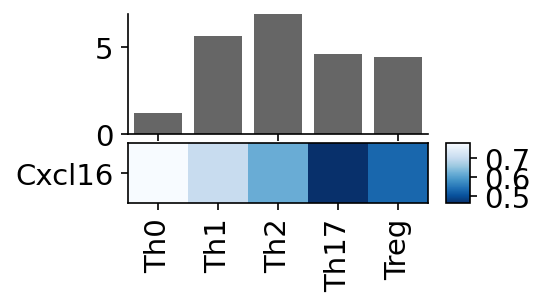

In [38]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Cxcr6',
    ligands=['Cxcl16'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day3',
    # vmin = 0.5,
    autoscale=True,
    cmap = 'Blues_r',
    bin_size_um=50,
    # show_binned=True,   
)
plt.savefig(os.path.join(plot_out_dir, f"HDM_day3_JSdist_Cxcr6_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

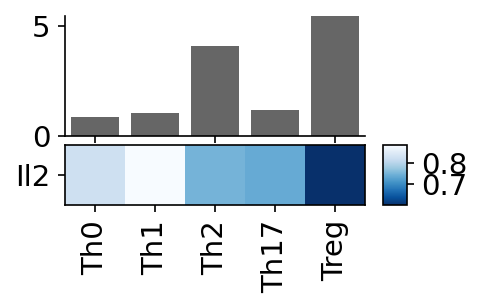

In [39]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Il2ra',
    ligands=['Il2'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day3',
    # vmin = 0.5,
    autoscale=True,
    cmap = 'Blues_r',
    bin_size_um=50,
    # show_binned=True,   
)
plt.savefig(os.path.join(plot_out_dir, f"HDM_day3_JSdist_Il2ra_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Unpack cell type expression of these DE ligands in each region

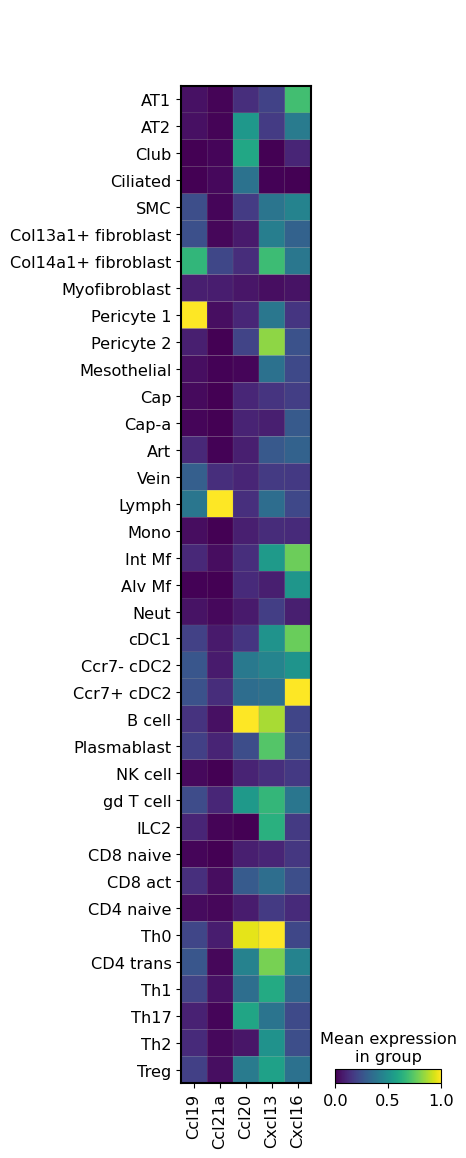

In [40]:
sample_label = 'HDM_day3'
adata_select = adata[adata.obs['sample_label']==sample_label,:]
sc.pl.matrixplot(adata_select, var_names = ['Ccl19', 'Ccl21a','Ccl20', 'Cxcl13','Cxcl16'], groupby='label_fine', standard_scale = 'var', swap_axes=False, show=False)
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_ligand_matrixplot.pdf"),bbox_inches='tight', transparent=True)

## Plot gene density in 2D plots

HDM_day3


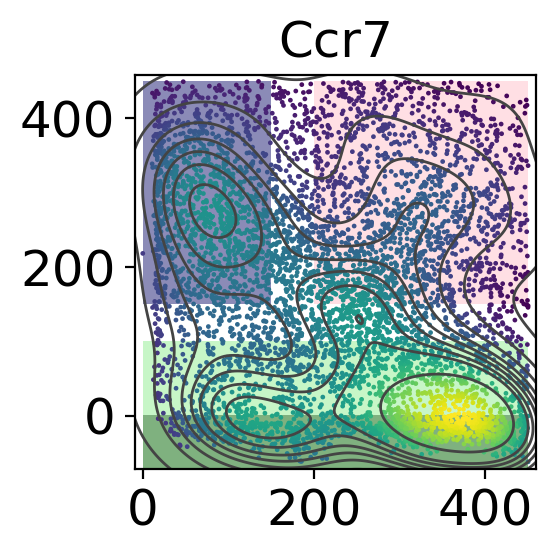

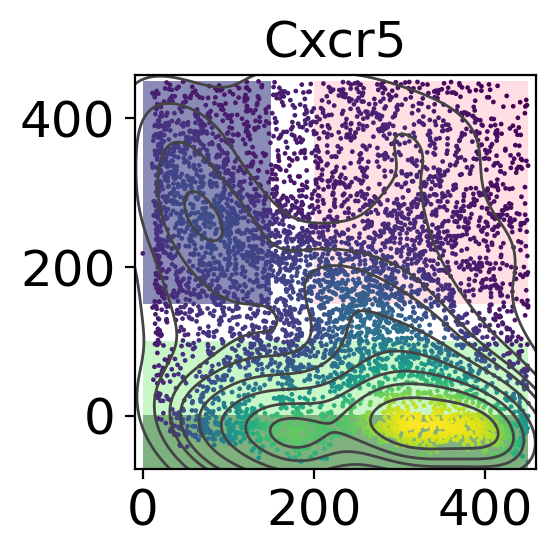

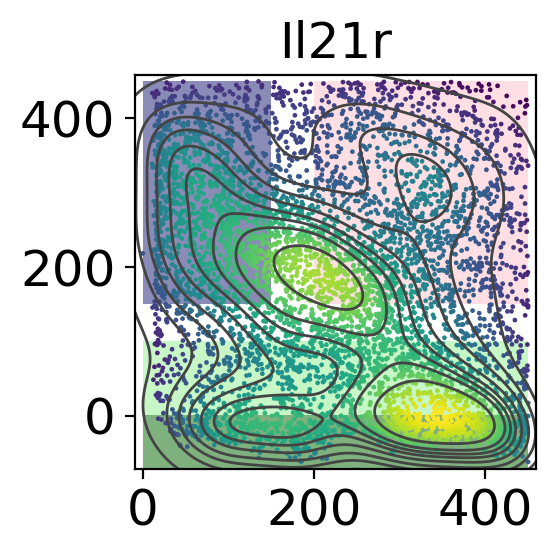

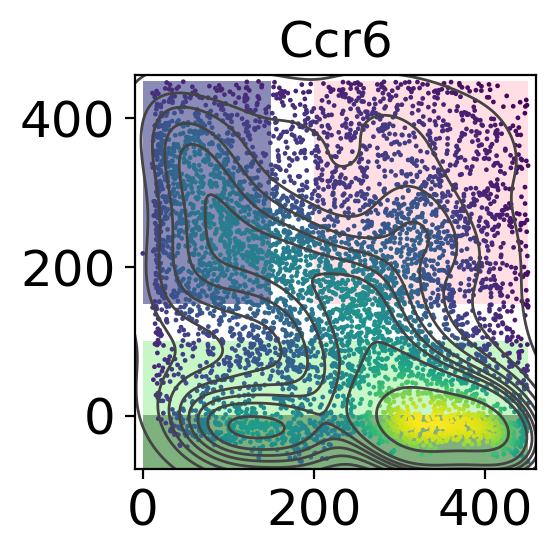

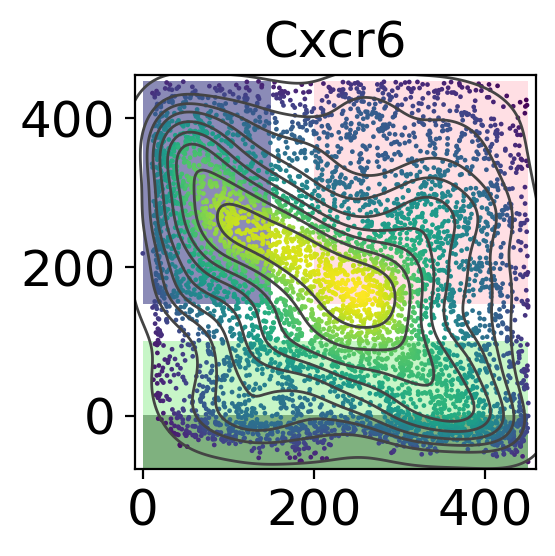

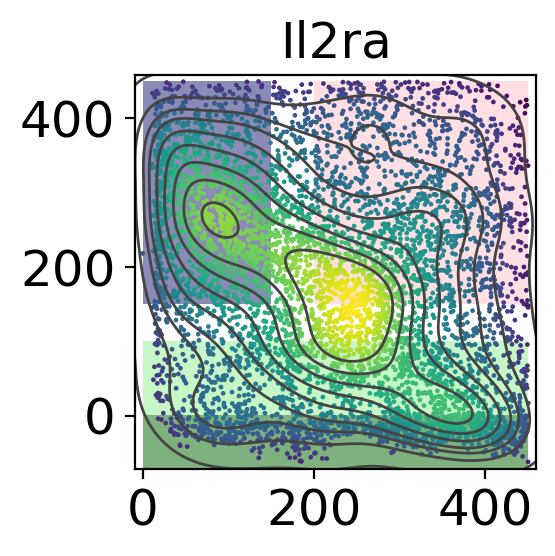

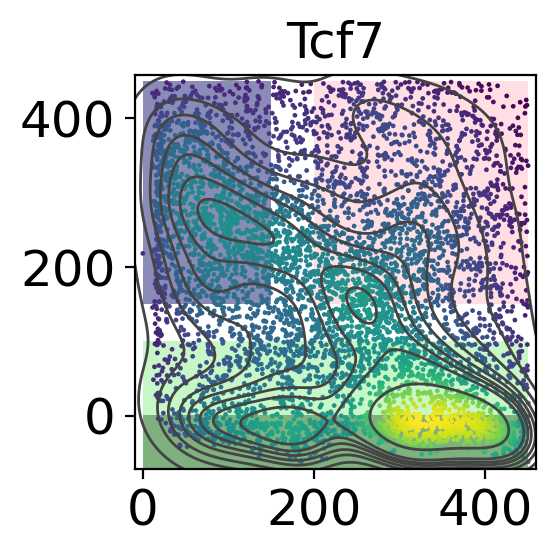

In [132]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
for gene_name in ['Ccr7', 'Cxcr5', 'Il21r', 'Ccr6',
                  'Cxcr6', 'Il2ra',
                 'Tcf7']:
    p = distance_xy_kde(adata_plot,
                    sample_label=[sample_label],
                    x_axis = 'avg_distance_to_bronchi_zone', y_axis = 'distance_to_tls',
                    gene_name = gene_name,
                    celltype_col = 'label_medium',celltype = 'CD4 act',
                    x_clip = 450, y_clip= 450,
                    gates = gates, gate_palette=gate_palette, point_size=2,gate_alpha = 0.5
                       )
    plt.savefig(os.path.join(plot_out_dir, f"2D_density_{celltype}_gates_{sample_label}_{gene_name}.pdf"), dpi=300, bbox_inches='tight', transparent=True)


## Run JS distance analysis on day 30 sample

In [41]:
res_d30 = rank_lr_js_delta(
    adata, df_lr,
    celltypes=['Th2','Th0'],      # delta = JS_Th2 - JS_Th0  (>0 = more co-localized with Th0)
    celltype_col='label_fine',
    sample='HDM_day30',
    bin_size_um=50, smooth_sigma=1.0,
    min_frac_pos=0.10,
)

In [42]:
res_d30.to_csv('d30_deltaJS_Th2-Th0.csv')

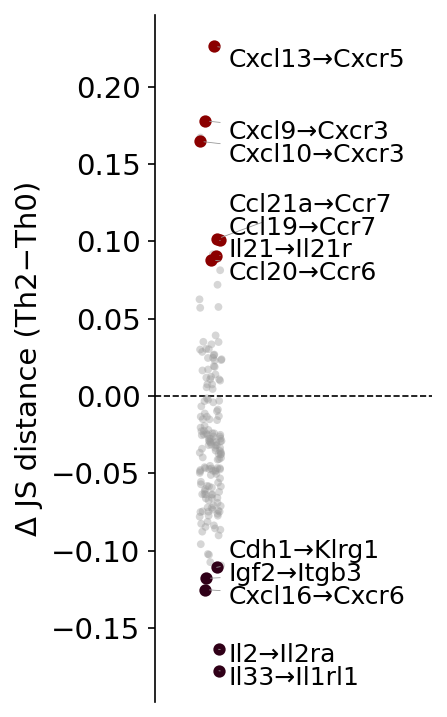

In [116]:
fig, ax = plot_js_delta_jitter(res_d30, 
                               pairs_to_label=[('Ccl19', 'Ccr7'), ('Cxcl9', 'Cxcr3'),('Cxcl10', 'Cxcr3'), ('Ccl21a', 'Ccr7'), ('Cxcl13','Cxcr5'), ('Il21', 'Il21r'), ('Ccl20', 'Ccr6'),
                                              ('Cxcl16', 'Cxcr6'), ('Il33','Il1rl1'), ('Cdh1', 'Klrg1'), ('Nmu','Nmur1'), ('Il2', 'Il2ra'), ('Igf2', 'Itgb3')],
                               pos_color='darkred', neg_color = '#300018')
plt.savefig(os.path.join(plot_out_dir, f"HDM_day30_deltaJS_Th0_Th2_jitter.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

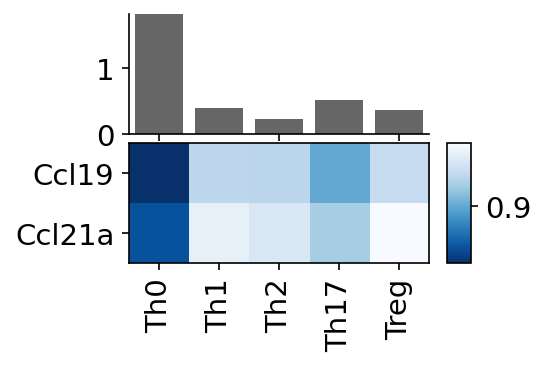

In [117]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Ccr7',
    ligands=['Ccl19', 'Ccl21a'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day30',
    autoscale=True,
    bin_size_um=50,
    cmap='Blues_r',     
)
plt.savefig(os.path.join(plot_out_dir, f"HDM_day30_JSdist_Ccr7_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

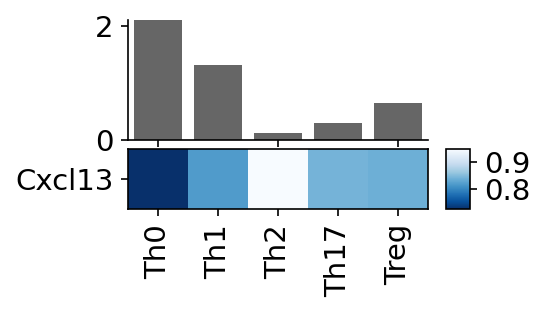

In [118]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Cxcr5',
    ligands=['Cxcl13'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day30',
    autoscale=True,
    bin_size_um=50,
    cmap='Blues_r',     
)
plt.savefig(os.path.join(plot_out_dir, f"HDM_day30_JSdist_Cxcr5_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

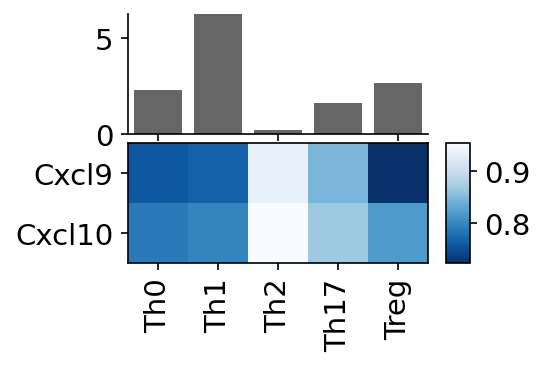

In [122]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Cxcr3',
    ligands=['Cxcl9', 'Cxcl10'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day30',
    autoscale=True,
    bin_size_um=50,
    cmap='Blues_r',     
)
plt.savefig(os.path.join(plot_out_dir, f"HDM_day30_JSdist_Cxcr3_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

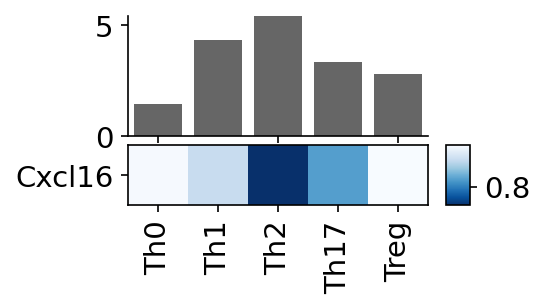

In [119]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Cxcr6',
    ligands=['Cxcl16'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day30',
    autoscale=True,
    bin_size_um=50,
    cmap='Blues_r',     
)
plt.savefig(os.path.join(plot_out_dir, f"HDM_day30_JSdist_Cxcr6_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

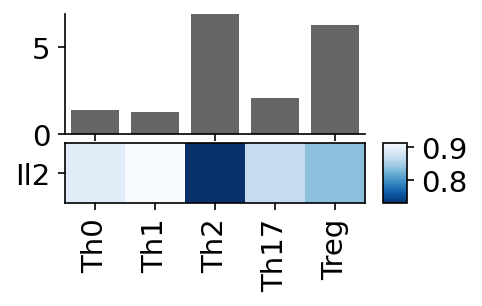

In [120]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Il2ra',
    ligands=['Il2'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day30',
    autoscale=True,
    bin_size_um=50,
    cmap='Blues_r',     
)
plt.savefig(os.path.join(plot_out_dir, f"HDM_day30_JSdist_Il2ra_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

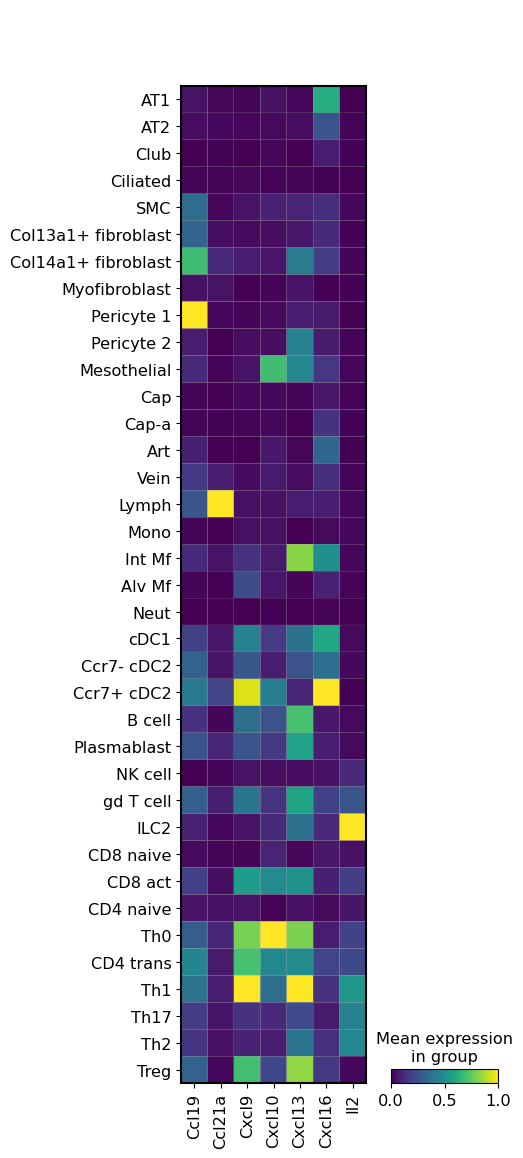

In [62]:
sample_label = 'HDM_day30'
adata_select = adata[adata.obs['sample_label']==sample_label,:]
sc.pl.matrixplot(adata_select, var_names = ['Ccl19', 'Ccl21a',
                                            'Cxcl9', 'Cxcl10',
                                            'Cxcl13','Cxcl16', 'Il2'], groupby='label_fine', standard_scale = 'var', swap_axes=False, show=False)
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_ligand_matrixplot_d30.pdf"),bbox_inches='tight', transparent=True)

HDM_day30


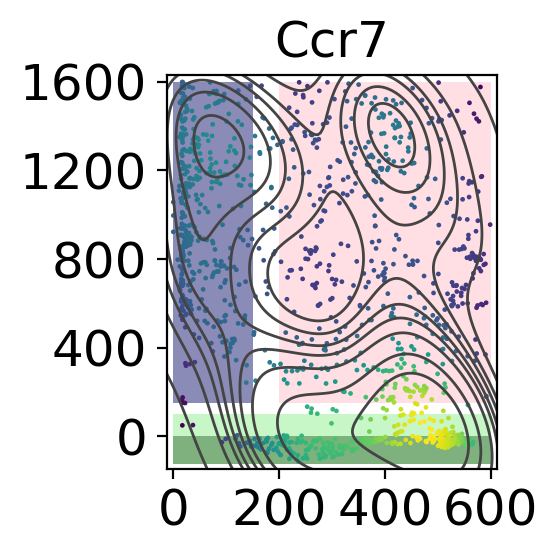

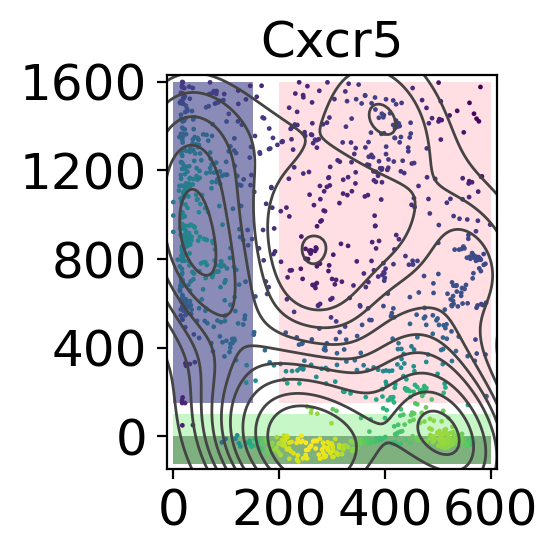

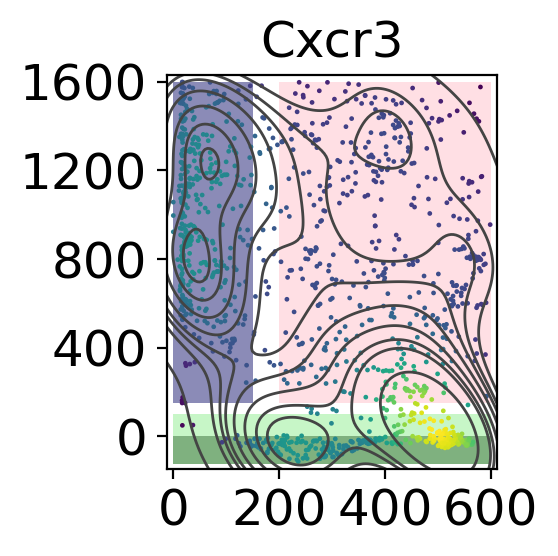

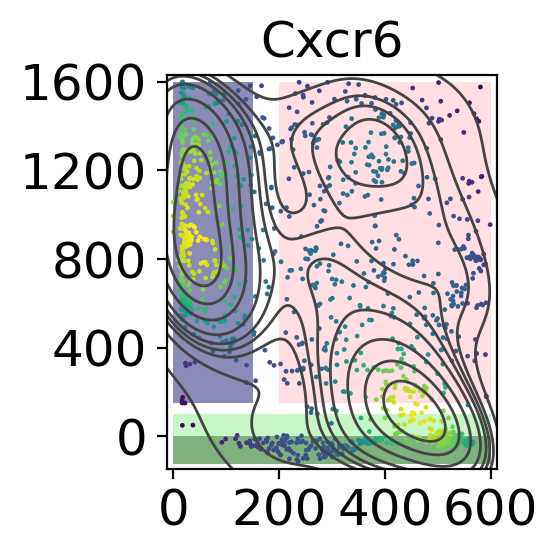

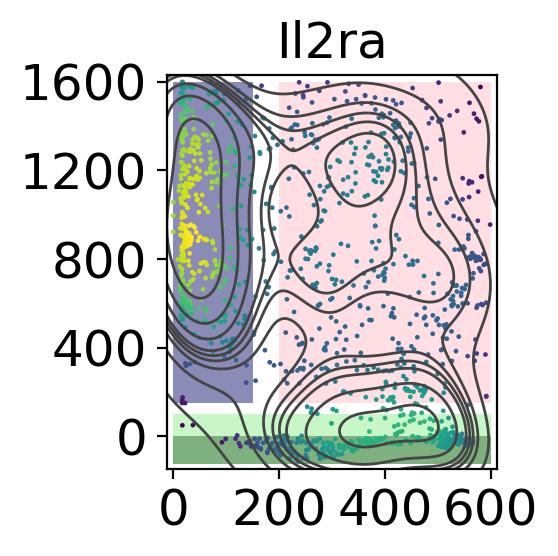

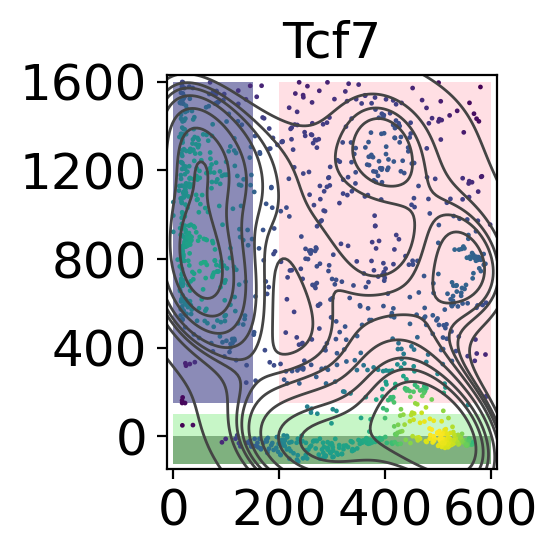

In [130]:
sample_label = 'HDM_day30'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
for gene_name in ['Ccr7', 'Cxcr5','Cxcr3', 
                  'Cxcr6', 'Il2ra',
                 'Tcf7']:
    p = distance_xy_kde(adata_plot,
                    sample_label=[sample_label],
                    x_axis = 'avg_distance_to_bronchi_zone', y_axis = 'distance_to_tls',
                    gene_name = gene_name,
                    celltype_col = 'label_medium',celltype = 'CD4 act',
                    x_clip = 600, y_clip= 1600,
                        x_ticks = [0,200,400,600], y_ticks = [0, 400, 800, 1200, 1600],
                    gates = gates, gate_palette=gate_palette, point_size=2,gate_alpha = 0.5
                       )
    plt.savefig(os.path.join(plot_out_dir, f"2D_density_{celltype}_gates_{sample_label}_{gene_name}.pdf"), dpi=300, bbox_inches='tight', transparent=True)


In [40]:
import session_info
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active conda environment:  space2
